Based on: https://github.com/icepack/icepack2/commits/75b5b1413af3ad7d584424f9b4e64ad0bc57988f/notebooks/mismipp-dual-1d.ipynb

In [1]:
"""
Initial imports and function declarations
"""

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm.notebook import tqdm, trange
import firedrake as fd
from firedrake import (
    eq,
    conditional,
    min_value,
    max_value,
    exp,
    sqrt,
    inner,
    sym,
    tr,
    grad,
    Constant,
    dx,
    ds,
    dS,
    avg,
    jump,
)
import irksome
from irksome import Dt, lag
from icepack.constants import (
    weertman_sliding_law,
    glen_flow_law,
    gravity as g,
    ice_density as ρ_I,
    water_density as ρ_W,
)

import ufl

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


## Definitions of the laws

In [2]:
def get_test_function(q):
    z, = ufl.algorithms.extract_coefficients(q)
    w = fd.TestFunction(z.function_space())
    return fd.replace(q, {z: w})


# redundant, use the imports instead
n = 3 #Constant(glen_flow_law)
m = 3 #Constant(weertman_sliding_law)

# fields are mutable state?
# parameters are immutable?
# This uses the global variable s, which is mutable. Should it be part of fields?
def friction_law(**kwargs):
    τ, u, h = map(kwargs.get, ("basal_stress", "velocity", "thickness"))

    parameters = ("sliding_coefficient", "sliding_exponent")
    K, m = map(kwargs.get, parameters)

    p_W = lag(ρ_W * g * max_value(0, -(s - h)))
    p_I = ρ_I * g * h
    r = Constant(0.99)
    ϕ = lag(conditional(p_W > r * p_I, 0, 1))

    σ = get_test_function(τ)
    τ_2 = inner(τ, τ)

    if m == 1:
        τ_m = Constant(1.0)
    elif m == 3:
        τ_m = τ_2
    elif m == 5:
        τ_m = τ_2 ** 2
    else:
        raise ValueError("Sliding law exponent must be in [1, 3, 5]!")

    f = ϕ if m == 1 else ϕ ** m
    return inner(K * τ_m * τ + f * u, σ) * dx


def flow_law(**kwargs):
    variables = ("velocity", "membrane_stress", "thickness")
    u, M, h = map(kwargs.get, variables)
    parameters = ("flow_law_coefficient", "flow_law_exponent")
    A, n = map(kwargs.get, parameters)

    N = get_test_function(M)
    d = mesh.geometric_dimension
    M_2 = (inner(M, M) - tr(M)**2 / (d + 1)) / 2

    if n == 1:
        M_n = Constant(1.0)
    elif n == 3:
        M_n = M_2
    elif n == 5:
        M_n = M_2 ** 2
    else:
        raise ValueError("Flow law exponent must be in [1, 3, 5]!")

    ε = sym(grad(u))
    return h * (A * M_n * (inner(M, N) - tr(M) * tr(N) / (d + 1)) - inner(ε, N)) * dx


def momentum_balance(**kwargs):
    variables = (
        "velocity", "membrane_stress", "basal_stress", "thickness", "surface"
    )
    u, M, τ, h, s = map(kwargs.get, variables)
    v = get_test_function(u)

    ε = sym(grad(v))
    cell_balance = (-h * inner(M, ε) + inner(τ - ρ_I * g * h * grad(s), v)) * dx

    ν = fd.FacetNormal(mesh)
    facet_balance = ρ_I * g * avg(h) * inner(jump(s, ν), avg(v)) * dS

    return cell_balance + facet_balance


def terminus(**kwargs):
    variables = ("velocity", "thickness", "surface", "terminus_ids")
    u, h, s, terminus_ids = map(kwargs.get, variables)
    v = get_test_function(u)

    d = fd.min_value(s - h, 0)
    τ_I = ρ_I * g * h**2 / 2
    τ_W = ρ_W * g * d**2 / 2

    ν = fd.FacetNormal(mesh)
    return (τ_I - τ_W) * inner(v, ν) * ds(terminus_ids)


def smooth_max(a, b, ϵ):
    return (a + b + ((a - b)**2 + ϵ**2) ** 0.5) / 2

def mass_balance(**kwargs):
    variables = ("thickness", "velocity", "accumulation", "thickness_in")
    h, u, a, h_in = map(kwargs.get, variables)
    η = get_test_function(h)

    ν = fd.FacetNormal(mesh)
    F_cells = (Dt(h) * η - inner(h * u, grad(η)) - a * η) * dx
    f = h * max_value(0, inner(u, ν))
    F_facets = jump(f) * jump(η) * dS
    F_outflow = f * η * ds
    F_inflow = h_in * min_value(0, inner(u, ν)) * η * ds
    return F_cells + F_facets + F_outflow + F_inflow

## Initialization and setting the values

In [3]:
"""
Initialization of the bed geometry and velocity/height profiles
"""

lx = 610e3
nx = 900

mesh = fd.IntervalMesh(nx, lx, name="mesh")
thickness_element = fd.FiniteElement("DG", "interval", 0)
bed_element = fd.FiniteElement("CG", "interval", 1)
degree = 1

velocity_element = fd.FiniteElement("CG", "interval", degree)
stress_element = fd.FiniteElement("DG", "interval", degree - 1)

Q = fd.FunctionSpace(mesh, thickness_element)
S = fd.FunctionSpace(mesh, bed_element)
V = fd.VectorFunctionSpace(mesh, velocity_element)
Σ = fd.TensorFunctionSpace(mesh, stress_element, symmetry=True)

Lx = Constant(lx)

In [4]:
"""
We utilize the mismip+ bed
"""
    
B_0 = Constant(-150)
B_2 = Constant(-728.8)
B_4 = Constant(343.91)
B_6 = Constant(-50.57)
x_c = Constant(300e3)


def mismip_bed(mesh):
    x, = fd.SpatialCoordinate(mesh)
    X = x / x_c
    B_x = B_0 + B_2 * X**2 + B_4 * X**4 + B_6 * X**6
    z_deep = Constant(-720)    
    return B_x

# currently unused
def linear_bed(mesh):
    x, = fd.SpatialCoordinate(mesh)
    b_in, b_out = 200, -400
    b_x = (b_in - (b_in - b_out) * x / Lx)
    return b_x

In [5]:
x = fd.SpatialCoordinate(mesh)[0]

b = fd.Function(S).interpolate(mismip_bed(mesh))

h_in = Constant(200.0)
δh = Constant(100.0)
h_expr = h_in - δh * x / Lx
h_0 = fd.Function(Q).interpolate(h_expr)
h = h_0.copy(deepcopy=True)

ϵ = Constant(0.1)
s_expr = smooth_max(b + h, (1 - ρ_I / ρ_W) * h, ϵ)
s0 = fd.Function(Q).interpolate(s_expr)
z_b = fd.Function(Q).interpolate(s0 - h)

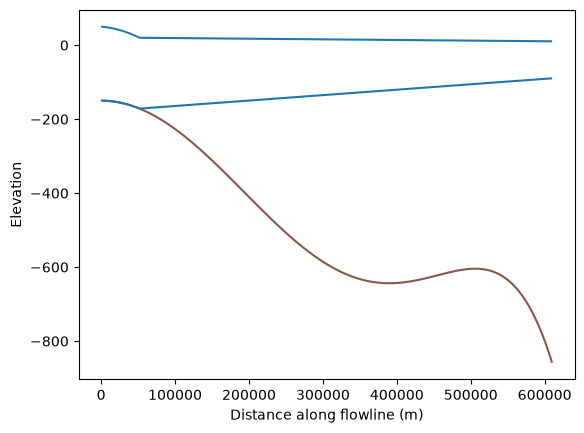

In [6]:
# Uses smoothed surface

fig, axes = plt.subplots()
fd.plot(b, axes=axes, edgecolor="tab:brown")
fd.plot(s0, axes=axes, edgecolor="tab:blue")
fd.plot(z_b, axes=axes, edgecolor="tab:blue")
axes.set_xlabel('Distance along flowline (m)')
axes.set_ylabel('Elevation')
plt.show()

---

## First Simulation Phase

* `h` is unchanged (value of h equals h0)
* `s` used without lag (and not smoothed)

In [7]:
δu = fd.Constant(90.0)
expr = fd.as_vector([δu * x / Lx])  # 1-component vector
u_0 = fd.Function(V).interpolate(expr)

In [8]:
A = Constant(20)
K = Constant(1e6)

τ_c = Constant(0.01)
ε_c = Constant(A * τ_c ** n)
u_c = Constant(K * τ_c ** m)

In [9]:
print(f"Strain rate: {1000 * float(ε_c):0.3f} m / yr / km")
print(f"Speed:       {float(u_c):0.3f} m / yr")
print(f"at stress of {1000 * float(τ_c):0.3f} kPa")

Strain rate: 0.020 m / yr / km
Speed:       1.000 m / yr
at stress of 10.000 kPa


In [10]:
"""
Initialization of function spaces and mass/momentum balance
"""

Z = V * Σ * V
z = fd.Function(Z)
z.sub(0).assign(u_0);

inflow_ids = (1,)
terminus_ids = (2,)

#s = smooth_max(b + h, (1 - ρ_I / ρ_W) * h, ϵ)
s = max_value(b + h, (1 - ρ_I / ρ_W) * h)

u, M, τ = fd.split(z)

# Mutable State (partially derived from z?)?
fields = {
    "velocity": u,
    "thickness": h,
    "surface": s,
    "membrane_stress": M,
    "basal_stress": τ,
}

parameters_1 = {
    "flow_law_coefficient": ε_c / τ_c,
    "flow_law_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
    "sliding_exponent": 1,
}

parameters_3 = {
    "flow_law_coefficient": ε_c / τ_c ** n,
    "flow_law_exponent": n,
    "sliding_coefficient": u_c / τ_c ** m,
    "sliding_exponent": m,
}

α = Constant(1e-3)
F_flow_law_1 = flow_law(**fields, **parameters_1)
F_flow_law_3 = flow_law(**fields, **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**fields, **parameters_1)
F_sliding_law_3 = friction_law(**fields, **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F = F_flow_law + F_sliding_law + F_balance + F_terminus

inflow_bc = fd.DirichletBC(Z.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

fparams = {"quadrature_degree": 8}
pparams = {"bcs": bcs, "form_compiler_parameters": fparams}
problem = fd.NonlinearVariationalProblem(F, z, **pparams)

logfile = ":mismipp-dual.log"
sparams = {
    "solver_parameters": {
        "snes_max_it": 200,
        "snes_linesearch_type": "nleqerr",
        "snes_monitor": logfile,
        "pc_factor_mat_solver_type": "umfpack",
    }
}
solver = fd.NonlinearVariationalSolver(problem, **sparams)
solver.solve()
u, M, τ = z.subfunctions

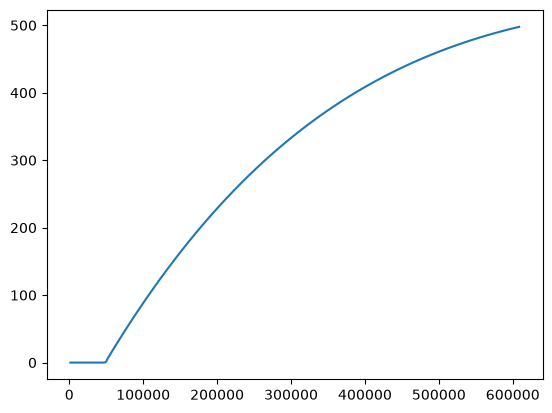

In [11]:
fig, axes = plt.subplots()
fd.plot(fd.Function(S).interpolate(u[0]), axes=axes);

---

## Second Simulation Phase

* `h` included in dynamics
* `s` uses lag

In [12]:
# Note that h is part of w

W = V * Σ * V * Q

w = fd.Function(W)
w.sub(0).assign(z.sub(0))
w.sub(1).assign(z.sub(1))
w.sub(2).assign(z.sub(2))
w.sub(3).assign(h);

In [13]:
inflow_bc = fd.DirichletBC(W.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

u, M, τ, h = fd.split(w)
v, N, σ, η = fd.TestFunctions(W)

s = lag(max_value(b + h, (1 - ρ_I / ρ_W) * h))
fields = {
    "velocity": u,
    "thickness": h,
    "surface": s,
    "membrane_stress": M,
    "basal_stress": τ,
}

h_min = Constant(1e-3)
regularized = {"thickness": max_value(h_min, h)}

H = Constant(500.0)

F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F_momentum = F_flow_law + F_sliding_law + F_balance + F_terminus

In [14]:
F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**(fields | regularized))
F_terminus = terminus(**(fields | regularized), terminus_ids=terminus_ids)

F_momentum_regularized = F_flow_law + F_sliding_law + F_balance + F_terminus

In [15]:
a_0 = Constant(1.0)
m_0 = Constant(1.125)
z_b = s - h
heaviside = lambda z: 1 / (1 + fd.exp(-z))
#a_expr = a_0 - m_0 * heaviside(-z_b) * heaviside(z_b - b)
a_expr = a_0 - m_0 * heaviside(z_b - b)

In [16]:
F_mass = mass_balance(
    thickness=h, velocity=u, accumulation=lag(a_expr), thickness_in=h_0
)
F = F_momentum + F_mass
Fp = F_momentum_regularized + F_mass

In [17]:
"""
Main driver:
"""

method = irksome.BackwardEuler()
t = Constant(0.0)
timestep = 1/12
dt = Constant(timestep)

fparams = {"quadrature_degree": 8}
sparams = {
    "snes_monitor": ":mismip-dual-ts.log",
    "snes_type": "vinewtonrsls",
    "snes_linesearch_type": "bt", 
    "snes_linesearch_max_it": 200,
    "snes_max_it": 1000,
    "snes_atol": 2e-8,
    "snes_rtol": 1e-4,
    "pc_factor_mat_solver_type": "mumps",
}
lower = fd.Function(W)
upper = fd.Function(W)
lower.assign(-np.inf)
lower.sub(3).assign(0.0)
upper.assign(+np.inf)

params = {
    "bcs": bcs,
    "form_compiler_parameters": fparams,
    "solver_parameters": sparams,
    "stage_type": "value",
    "basis_type": "Bernstein",
    "bounds": ("stage", lower, upper)
}

# From here on h0 and h differ!

solver = irksome.TimeStepper(F, method, t, dt, w, **params, Jp=Fp)

In [18]:
final_time = 6000.0
num_steps = int(final_time / timestep)

timesteps = np.linspace(0, final_time, num_steps + 1)

ws = [w.copy(deepcopy=True)]

# if load cache success: w = loaded w
# else: run solver and store resulting w
with fd.CheckpointFile('mismip-steady-state.h5', "w") as chk:
    chk.save_mesh(mesh)
    for step in trange(num_steps):
        solver.advance()
        ws.append(w.copy(deepcopy=True))

    chk.save_function(b, name="bed")
    chk.save_function(w, name="mono")

  0%|          | 0/72000 [00:00<?, ?it/s]

## Functions for Analysis

### Determining the Terminus

For calving events we need to know where the terminus is to be able to determine where the new terminus should be after the calving has occurred. 
In most cases, and assumed in my approach so far, the terminus is just the first point where the thickness function is zero. 
1. The first function I have defined finds this spot by creating a vertex only mesh for each integer value along the flow line (so for every meter) and then using np.where() to find the first value where it is zero. This is numerically quite expensive. 
A bit of a speed-up is achieved by making the spacing of the mesh larger, though for this to work one needs to multiply the result by the spacing that was used (since np.where returns the value's spot in the list of not its coordinates).
2. Another option is to access the values of the function at the nodes of the mesh using '.dat.data_ro'. This is an attribute of the function and is therefore quite fast.
The problem with this approach is that there are only 450 intervals, so the step sizes are about 1335 which means the actual terminus position can be up to 1.3 km further to the left.
This one is the winner because the thickness is constant on each element anyways.
3. The next option would be to combine these two approaches. This would mean first finding the interval in which the terminus lies and then using creating a finer vertex only mesh on that interval to find the exact position. It turns out this is actually way too intense and the whole kernel crashes when I attempt to do this.

In [19]:
def end_of_glacier_slow(f, accuracy=1):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_init_values = f.dat.data_ro # faster but less data point way to access the values of f
    if f_init_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    f_mesh = fd.Function(f).ufl_domain()
    points = np.arange(0, 610_000, accuracy)[:, None] # list of lists (requirement for the vertex only mesh)
    vom = fd.VertexOnlyMesh(f_mesh, points)
    P = fd.FunctionSpace(vom, "DG", 0)
    f_at_points = fd.assemble(fd.interpolate(f, P)) 
    f_values = f_at_points.dat.data_ro

    # if f_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
    #     return 'empty'
    zeros = np.where(f_values==0)[0]

    return zeros[0]*accuracy # this gives us the first point at which the thickness is zero

In [20]:
def end_of_glacier_fast(f):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_values = f.dat.data_ro # if hasattr(f, "dat") else fd.Function(f).dat.data_ro
    n = len(f_values)

    f_mesh = fd.Function(f).ufl_domain()
    length = fd.assemble(Constant(1.0) * dx(domain=f_mesh))

    # print(f_values)
    zeros = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]
    # print(zeros)


    if len(zeros) == 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    return int(zeros[0]*(length/n)) # this gives us the first point at which the thickness is zero

In [21]:
def end_of_glacier_node(f, elements=nx):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first node (of the mesh) where f is zero.
    """
    f_values = f.dat.data_ro # if hasattr(f, "dat") else fd.Function(f).dat.data_ro
    n = len(f_values)
    
    # print(f_values)
    zeros = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]
    # print(zeros)

    if len(zeros) == 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    return int(zeros[0]/(n/elements))

### Determining the Mass of the Glacier

In [22]:
def integrate(func):
    return fd.assemble(func* dx)

### Miscellaneous Tools

In [23]:
def logistic_function(y, new_term, k=10):
    """A variation on the logistic function that is 1 at -∞ and 0 at ∞ and continuously moves between the two centered at new_term. 
    The steepness of the transition is given by k."""
    # x = ufl.SpatialCoordinate(Q)
    return 1-1/(1+ufl.exp(-k*(y-new_term)))

In [24]:
def glacier_over_time(term_list, property):
    """
    This function takes a list of values and then creates an x-axis that 
    enumerates the points. In this context this is useful for plottting a property 
    that we are tracking over time (so for each time step).
    """
    n = len(term_list)
    x_list = np.arange(n)
    _, ax = plt.subplots()
    ax.set_title(f"{property} over Time")
    ax.set_xlabel("Timesteps (month)")
    ax.set_ylabel(f"{property}")
    plt.grid()
    # ax.set_ylim(100_000, 600_000)
    return ax.plot(x_list, term_list)

## Analyzing and Plotting the Results

In [25]:
u, M, τ, h = w.subfunctions # w is a field consisting of velocity, membrane stress, basal stress, thickness

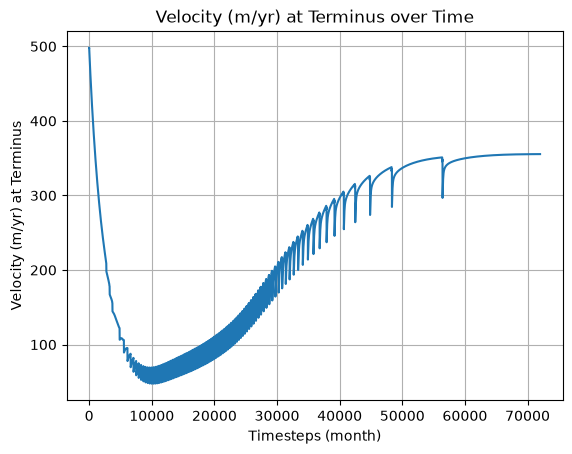

In [26]:
# this plot shows the velocity at approximatley the terminus of the glacier

terminus_velocities = []
for w in ws:
    u = w.sub(0)
    h = w.sub(3)
    node = end_of_glacier_node(h)
    u_at_points = u.dat.data_ro

    if node == 'empty':
        terminus_velocities += [u_at_points[-1]]
    else:
        terminus_velocities += [u_at_points[node]]

glacier_over_time(terminus_velocities, "Velocity (m/yr) at Terminus");

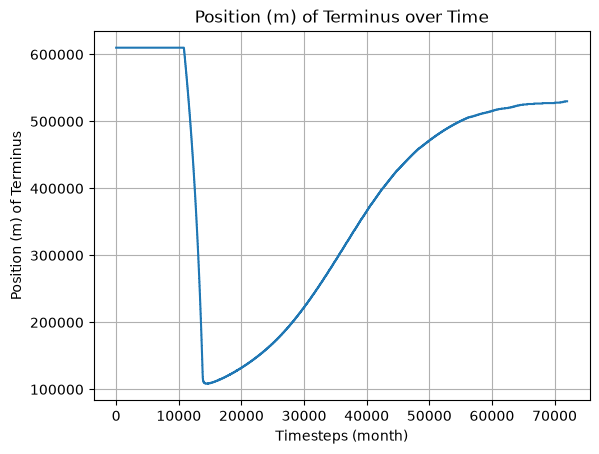

In [37]:
# plot of terminus position

terminus_positions = []
for w in ws:
    h = w.sub(3)
    node = end_of_glacier_fast(h)

    if node == 'empty':
        terminus_positions += [lx]
    else:
        terminus_positions += [node]

# print(terminus_positions)

glacier_over_time(terminus_positions, "Position (m) of Terminus");

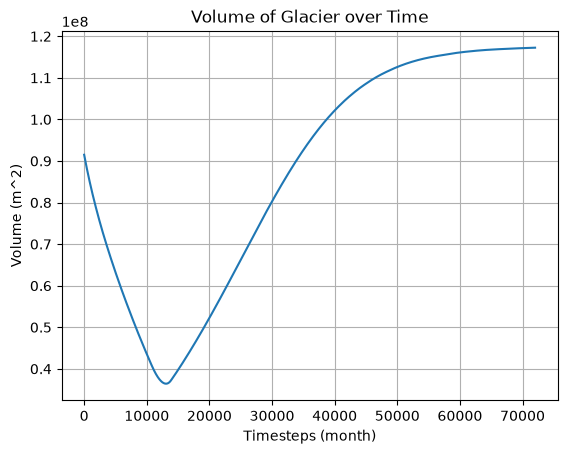

In [28]:
volume_list = []
for w in ws:
    h = w.sub(3)
    volume_list += [integrate(h)]

n = len(volume_list)
x_list = np.arange(n)
_, ax = plt.subplots()
ax.set_title(f"Volume of Glacier over Time")
ax.set_xlabel("Timesteps (month)")
ax.set_ylabel(f"Volume (m^2)")
plt.grid()
ax.plot(x_list, volume_list);

In [33]:
print(len(volume_list))

72001


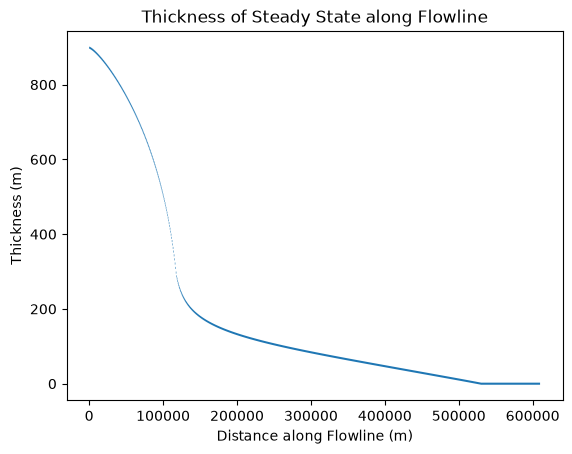

In [29]:
# a plot of the thickness function
fig, ax = plt.subplots()
ax.set_title("Thickness of Steady State along Flowline")
ax.set_xlabel("Distance along Flowline (m)")
ax.set_ylabel("Thickness (m)")
fd.plot(h, axes=ax);

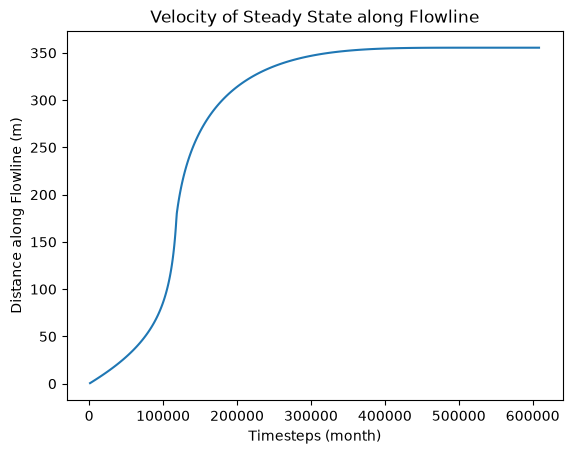

In [30]:
# a plot of the velocity function
fig, ax = plt.subplots()
ax.set_title("Velocity of Steady State along Flowline")
ax.set_xlabel("Timesteps (month)")
ax.set_ylabel("Distance along Flowline (m)")
fd.plot(fd.Function(S).interpolate(u[0]), axes=ax);

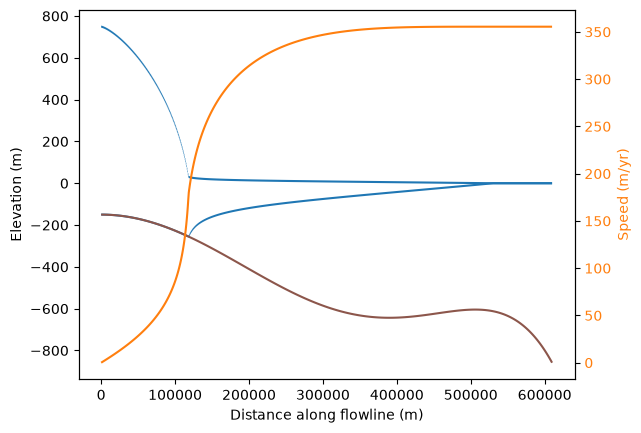

In [31]:
s = fd.Function(Q).interpolate(max_value(b + h, (1 - ρ_I / ρ_W) * h)) # surface of the glacier
z_b = fd.Function(Q).interpolate(s - h) # base of the glacier

fig, ax = plt.subplots()
ax.set_xlabel("Distance along flowline (m)")
ax.set_ylabel("Elevation (m)")
fd.plot(s, edgecolor="tab:blue", axes=ax)
fd.plot(z_b, edgecolor="tab:blue", axes=ax)
fd.plot(b, edgecolor="tab:brown", axes=ax)

ax = ax.twinx()
ax.set_ylabel("Speed (m/yr)", color="tab:orange")
ax.tick_params(axis="y", labelcolor="tab:orange")
u_x = fd.Function(S).interpolate(u[0])
fd.plot(u_x, edgecolor="tab:orange", axes=ax);

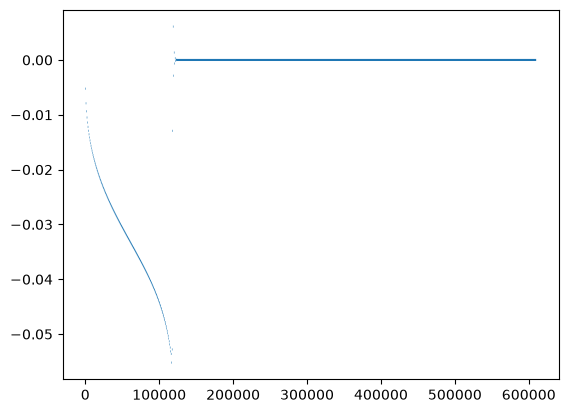

In [32]:
τ_b = fd.Function(Q).project(τ[0])
fig, ax = plt.subplots()
fd.plot(τ_b, axes=ax);